# 2025년 12월 행정동 통합 EDA

`2025.12월_10개 관심집단수.csv`, `2025.12월_29개 통신정보.csv`, `행정구역_읍면동_별_5세별_인구.csv`를 결합해 행정동 기준 인사이트를 도출합니다.

- 분석 단위: 행정동 중심
- 결합 레벨: `행정동코드 + 성별 + 연령대` 후 행정동 집계
- 목표: 관심집단 특성과 통신/이동 행동 특성을 함께 반영한 행정동 인사이트 강화


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="talk")

font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    rcParams["font.family"] = selected_font
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 일부 그래프 레이블이 깨질 수 있습니다.")
rcParams["axes.unicode_minus"] = False


In [2]:
base_path = Path.cwd()
csv_paths = sorted(base_path.glob("*.csv"), key=lambda p: p.stat().st_size)

pop_path = csv_paths[0]
interest_path = csv_paths[1]
telecom_path = csv_paths[2]

print("공공 인구 파일:", pop_path.name)
print("관심집단 파일:", interest_path.name)
print("통신정보 파일:", telecom_path.name)


공공 인구 파일: 행정구역_읍면동_별_5세별_인구.csv
관심집단 파일: 2025.12월_10개 관심집단수.csv
통신정보 파일: 2025.12월_29개 통신정보.csv


In [3]:
interest_raw = pd.read_csv(interest_path, encoding="utf-8-sig")
telecom_raw = pd.read_csv(telecom_path, encoding="utf-8-sig")
pop_raw = pd.read_csv(pop_path, encoding="utf-8-sig", header=None)
pop_raw.columns = ["지역", "항목", "값"]

interest_raw = interest_raw.loc[:, [c for c in interest_raw.columns if str(c).strip() and not str(c).startswith("Unnamed:")]].copy()
telecom_raw = telecom_raw.loc[:, [c for c in telecom_raw.columns if str(c).strip() and not str(c).startswith("Unnamed:")]].copy()
pop_raw = pop_raw.dropna(subset=["지역"]).copy()

print("관심집단 shape:", interest_raw.shape)
print("통신정보 shape:", telecom_raw.shape)
print("공공 인구 shape:", pop_raw.shape)

display(interest_raw.head(2))
display(telecom_raw.head(2))
display(pop_raw.head(5))


관심집단 shape: (10176, 17)
통신정보 shape: (10176, 143)
공공 인구 shape: (453, 3)


,행정동코드,자치구,행정동명,성별,연령대,총인구,1인가구수,커뮤니케이션이 적은 집단,평일 외출이 적은 집단,휴일 외출이 적은 집단,출근소요시간 및 근무시간이 많은 집단,외출이 매우 적은 집단(전체),외출이 매우 많은 집단,동영상서비스 이용이 많은 집단,생활서비스 이용이 많은 집단,재정상태에 대한 관심집단,외출-커뮤니케이션이 모두 적은 집단(전체)
0,1101053,종로구,사직동,1,20,173,52,3,6,7,7,3,4,7,1,2,0
1,1101053,종로구,사직동,1,25,300,93,12,9,8,14,9,9,16,10,13,28


,행정동코드,자치구,행정동,성별,연령대,총인구수,1인가구수,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,"야간상주지 변경횟수: 4분위수, 25%","야간상주지 변경횟수: 4분위수, 50%","야간상주지 변경횟수: 4분위수, 75%",주간상주지 변경 미추정 인구수,주간상주지 변경횟수 평균,"주간상주지 변경횟수: 4분위수, 25%","주간상주지 변경횟수: 4분위수, 50%","주간상주지 변경횟수: 4분위수, 75%",출근 소요시간 미추정 인구수,평균 출근 소요시간 평균,"평균 출근 소요시간: 4분위수, 25%","평균 출근 소요시간: 4분위수, 50%","평균 출근 소요시간: 4분위수, 75%",근무시간 미추정 인구수,평균 근무시간 평균,"평균 근무시간: 4분위수, 25%","평균 근무시간: 4분위수, 50%","평균 근무시간: 4분위수, 75%",소액결재 비사용 인구수,소액결재 사용횟수 평균,"소액결재 사용횟수: 4분위수, 25%","소액결재 사용횟수: 4분위수, 50%","소액결재 사용횟수: 4분위수, 75%",소액결재 사용 금액 없는 인구수,소액결재 사용금액 평균,"소액결재 사용금액: 4분위수, 25%","소액결재 사용금액: 4분위수, 50%","소액결재 사용금액: 4분위수, 75%",최근 3개월 내 요금 연체 비율,카카오톡 비사용 인구수,SNS 사용횟수,"SNS 사용횟수: 4분위수, 25%","SNS 사용횟수: 4분위수, 50%","SNS 사용횟수: 4분위수, 75%",평균 통화량,"평균 통화량: 4분위수, 25%","평균 통화량: 4분위수, 50%","평균 통화량: 4분위수, 75%",평균 문자량,"평균 문자량: 4분위수, 25%","평균 문자량: 4분위수, 50%","평균 문자량: 4분위수, 75%",평균 통화대상자 수,"평균 통화대상자 수: 4분위수, 25%","평균 통화대상자 수: 4분위수, 50%","평균 통화대상자 수: 4분위수, 75%",평균 문자대상자 수,"평균 문자대상자 수: 4분위수, 25%","평균 문자대상자 수: 4분위수, 50%","평균 문자대상자 수: 4분위수, 75%",데이터 사용량,"데이터 사용량: 4분위수, 25%","데이터 사용량: 4분위수, 50%","데이터 사용량: 4분위수, 75%",평일 총 이동 횟수 미추정 인구수,평일 총 이동 횟수,"평일 총 이동 횟수: 4분위수, 25%","평일 총 이동 횟수: 4분위수, 50%","평일 총 이동 횟수: 4분위수, 75%",휴일 이동 미추정 인구수,휴일 총 이동 횟수 평균,"휴일 총 이동 횟수: 4분위수, 25%","휴일 총 이동 횟수: 4분위수, 50%","휴일 총 이동 횟수: 4분위수, 75%",집 추정 위치 평일 총 체류시간 미추정 인구수,집 추정 위치 평일 총 체류시간,"집 추정 위치 평일 총 체류시간: 4분위수, 25%","집 추정 위치 평일 총 체류시간: 4분위수, 50%","집 추정 위치 평일 총 체류시간: 4분위수, 75%",집 추정 위치 휴일 총 체류시간 미추정 인구수,집 추정 위치 휴일 총 체류시간,"집 추정 위치 휴일 총 체류시간: 4분위수, 25%","집 추정 위치 휴일 총 체류시간: 4분위수, 50%","집 추정 위치 휴일 총 체류시간: 4분위수, 75%",평일 총 이동 거리 미추정 인구수,평일 총 이동 거리 합계,"평일 총 이동 거리 합계: 4분위수, 25%","평일 총 이동 거리 합계: 4분위수, 50%","평일 총 이동 거리 합계: 4분위수, 75%",휴일 총 이동 거리 미추정 인구수,휴일 총 이동 거리 합계,"휴일 총 이동 거리 합계: 4분위수, 25%","휴일 총 이동 거리 합계: 4분위수, 50%","휴일 총 이동 거리 합계: 4분위수, 75%",지하철 이용 미추정 인구수,지하철이동일수 합계,"지하철이동일수 합계: 4분위수, 25%","지하철이동일수 합계: 4분위수, 50%","지하철이동일수 합계: 4분위수, 75%",게임 서비스 사용 미추정 인구수,게임 서비스 사용일수,"게임 서비스 사용일수: 4분위수, 25%","게임 서비스 사용일수: 4분위수, 50%","게임 서비스 사용일수: 4분위수, 75%",금융 서비스 사용 미추정 인구수,금융 서비스 사용일수,"금융 서비스 사용일수: 4분위수, 25%","금융 서비스 사용일수: 4분위수, 50%","금융 서비스 사용일수: 4분위수, 75%",쇼핑 서비스 사용 미추정 인구수,쇼핑 서비스 사용일수,"쇼핑 서비스 사용일수: 4분위수, 25%","쇼핑 서비스 사용일수: 4분위수, 50%","쇼핑 서비스 사용일수: 4분위수, 75%",동영상/방송 서비스 사용 미추정 인구수,동영상/방송 서비스 사용일수,"동영상/방송 서비스 사용일수: 4분위수, 25%","동영상/방송 서비스 사용일수: 4분위수, 50%","동영상/방송 서비스 사용일수: 4분위수, 75%",유튜브 사용 미추정 인구수,유튜브 사용일수,"유튜브 사용일수: 4분위수, 25%","유튜브 사용일수: 4분위수, 50%","유튜브 사용일수: 4분위수, 75%",넷플릭스 사용 미추정 인구수,넷플릭스 사용일수,"넷플릭스 사용일수: 4분위수, 25%","넷플릭스 사용일수: 4분위수, 50%","넷플릭스 사용일수: 4분위수, 75%",배달 서비스 사용 미추정 인구수,배달 서비스 사용일수,"배달 서비스 사용일수: 4분위수, 25%","배달 서비스 사용일수: 4분위수, 50%","배달 서비스 사용일수: 4분위수, 75%",배달_브랜드 서비스 사용 미추정 인구수,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%"
0,1101053,종로구,사직동,1,20,173,52,0,13.6000,14,14,14,3,9.0000,6,10,11,85,73.6000,30,50,110,74,540.3000,390,560,700,170,1.7000,1.7000,1.7000,1.7000,167,"4,000.0000",666.7000,666.7000,"7,333.3000",6.5600,3,0.1000,-0.1000,0.1000,0.2000,51.6000,10.0000,20.0000,73.3000,13.7000,3.3000,3.3000,6.7000,5.7000,3.3000,5.0000,6.7000,2.7000,1.7000,1.7000,3.3000,24.3000,8.4000,17.3000,36.0000,3,20.0000,11.7000,21.7000,26.7000,6,9.6000,5.0000,10.0000,13.3000,0,"610,882.5000","490,933.3000","657,433.3000","749,466.7000",0,"142,683.1000","110,966.7000","140,933.3000","171,166.7000",3,705.6000,233.3000,566.7000,766.7000,11,535.1000,133.3000,433.3000,700.0000,17,9.0000,5.0000,8.3000,13.3000,0,137.1000,83.3000,135.0000,195.0000,0,217.0000,125.0000,186.7000,275.0000,0,264.3000,161.7000,268.3000,338.3000,0,88.4000,55.0000,83.3000,121.7000,0,0.3000,0.2000,0.3000,0.4000,23,-0.1000,-0.5000,0.0000,0.2000,3,15.0000,6.7000,13.3000,20.0000,99,3.3000,1.7000,3.3000,3.3000,173,0.0000,0.0000,0.0000,0.0000
1,1101053,종로구,사직동,1,25,300,93,0,12.3000,13,14,14,30,9.4000,5,11,14,151,62.2000,20,40,80,130,562.9000,490,600,700,293,2.2000,1.7000,1.7

,지역,항목,값
0,서울특별시,총인구수 (명),"9,304,400"
1,종로구,총인구수 (명),"136,817"
2,청운효자동,총인구수 (명),"10,799"
3,사직동,총인구수 (명),"8,893"
4,삼청동,총인구수 (명),"2,095"


## 1. 전처리 및 병합 준비

세 파일을 같은 행정동 기준으로 보기 위해 이름 표기와 숫자형 컬럼을 정리합니다.  
공공 인구 파일은 계층형 텍스트 구조라서 `자치구-행정동-총인구` 형태로 재구성합니다.


In [4]:
SPACE_PATTERN = re.compile(r"^[\s\u3000]+")

def strip_leading_space(text):
    return SPACE_PATTERN.sub("", str(text)).strip()

def leading_len(text):
    matched = SPACE_PATTERN.match(str(text))
    return len(matched.group(0)) if matched else 0

def normalize_dong_name(text):
    s = str(text).strip()
    s = s.replace("·", ".")
    s = re.sub(r"제(?=\d)", "", s)
    s = re.sub(r"\s+", "", s)
    return s

def to_numeric_series(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip().replace({"": np.nan, "nan": np.nan}),
        errors="coerce",
    )

interest = interest_raw.copy()
telecom = telecom_raw.copy()

interest.columns = [str(c).strip() for c in interest.columns]
telecom.columns = [str(c).strip() for c in telecom.columns]
telecom = telecom.rename(columns={"행정동": "행정동명", "총인구수": "총인구_통신정보", "1인가구수": "1인가구수_통신정보"})

interest_id_cols = ["행정동코드", "자치구", "행정동명", "성별", "연령대"]
telecom_id_cols = ["행정동코드", "자치구", "행정동명", "성별", "연령대"]

for col in interest.columns:
    if col not in interest_id_cols:
        interest[col] = to_numeric_series(interest[col])

for col in telecom.columns:
    if col not in telecom_id_cols:
        telecom[col] = to_numeric_series(telecom[col])

for col in ["행정동코드", "성별", "연령대"]:
    interest[col] = pd.to_numeric(interest[col], errors="coerce").astype("Int64")
    telecom[col] = pd.to_numeric(telecom[col], errors="coerce").astype("Int64")

interest["성별라벨"] = interest["성별"].map({1: "남성", 2: "여성"}).fillna("기타")

pop_work = pop_raw.copy()
pop_work["들여쓰기"] = pop_work["지역"].map(leading_len)
pop_work["지역정리"] = pop_work["지역"].map(strip_leading_space)

current_gu = None
pop_rows = []
for _, row in pop_work.iterrows():
    if row["들여쓰기"] == 3:
        current_gu = row["지역정리"]
    elif row["들여쓰기"] == 6 and current_gu is not None:
        pop_rows.append(
            {
                "자치구": current_gu,
                "행정동명_공공": row["지역정리"],
                "행정동총인구_공공": pd.to_numeric(str(row["값"]).replace(",", ""), errors="coerce"),
            }
        )

pop_df = pd.DataFrame(pop_rows)
pop_df["행정동명_norm"] = pop_df["행정동명_공공"].map(normalize_dong_name)
interest["행정동명_norm"] = interest["행정동명"].map(normalize_dong_name)
telecom["행정동명_norm"] = telecom["행정동명"].map(normalize_dong_name)

print("공공 인구 행정동 수:", len(pop_df))
display(pop_df.head())


공공 인구 행정동 수: 427


,자치구,행정동명_공공,행정동총인구_공공,행정동명_norm
0,종로구,청운효자동,10799,청운효자동
1,종로구,사직동,8893,사직동
2,종로구,삼청동,2095,삼청동
3,종로구,부암동,8874,부암동
4,종로구,평창동,16986,평창동


In [5]:
merge_keys = ["행정동코드", "자치구", "행정동명", "성별", "연령대"]
merge_status = interest[merge_keys].merge(
    telecom[merge_keys],
    on=merge_keys,
    how="outer",
    indicator=True,
)

print("관심집단-통신정보 키 병합 상태")
print(merge_status["_merge"].value_counts())

merged_cell = interest.merge(
    telecom.drop(columns=["자치구", "행정동명_norm"]),
    on=["행정동코드", "행정동명", "성별", "연령대"],
    how="left",
    suffixes=("", "_통신"),
)

print("병합 후 셀 단위 shape:", merged_cell.shape)
display(merged_cell.head(2))


관심집단-통신정보 키 병합 상태
_merge
both          10176
left_only         0
right_only        0
Name: count, dtype: int64


병합 후 셀 단위 shape: (10176, 157)


,행정동코드,자치구,행정동명,성별,연령대,총인구,1인가구수,커뮤니케이션이 적은 집단,평일 외출이 적은 집단,휴일 외출이 적은 집단,출근소요시간 및 근무시간이 많은 집단,외출이 매우 적은 집단(전체),외출이 매우 많은 집단,동영상서비스 이용이 많은 집단,생활서비스 이용이 많은 집단,재정상태에 대한 관심집단,외출-커뮤니케이션이 모두 적은 집단(전체),성별라벨,행정동명_norm,총인구_통신정보,1인가구수_통신정보,야간상주지 변경 미추정 인구 수,야간상주지 변경횟수 평균,"야간상주지 변경횟수: 4분위수, 25%","야간상주지 변경횟수: 4분위수, 50%","야간상주지 변경횟수: 4분위수, 75%",주간상주지 변경 미추정 인구수,주간상주지 변경횟수 평균,"주간상주지 변경횟수: 4분위수, 25%","주간상주지 변경횟수: 4분위수, 50%","주간상주지 변경횟수: 4분위수, 75%",출근 소요시간 미추정 인구수,평균 출근 소요시간 평균,"평균 출근 소요시간: 4분위수, 25%","평균 출근 소요시간: 4분위수, 50%","평균 출근 소요시간: 4분위수, 75%",근무시간 미추정 인구수,평균 근무시간 평균,"평균 근무시간: 4분위수, 25%","평균 근무시간: 4분위수, 50%","평균 근무시간: 4분위수, 75%",소액결재 비사용 인구수,소액결재 사용횟수 평균,"소액결재 사용횟수: 4분위수, 25%","소액결재 사용횟수: 4분위수, 50%","소액결재 사용횟수: 4분위수, 75%",소액결재 사용 금액 없는 인구수,소액결재 사용금액 평균,"소액결재 사용금액: 4분위수, 25%","소액결재 사용금액: 4분위수, 50%","소액결재 사용금액: 4분위수, 75%",최근 3개월 내 요금 연체 비율,카카오톡 비사용 인구수,SNS 사용횟수,"SNS 사용횟수: 4분위수, 25%","SNS 사용횟수: 4분위수, 50%","SNS 사용횟수: 4분위수, 75%",평균 통화량,"평균 통화량: 4분위수, 25%","평균 통화량: 4분위수, 50%","평균 통화량: 4분위수, 75%",평균 문자량,"평균 문자량: 4분위수, 25%","평균 문자량: 4분위수, 50%","평균 문자량: 4분위수, 75%",평균 통화대상자 수,"평균 통화대상자 수: 4분위수, 25%","평균 통화대상자 수: 4분위수, 50%","평균 통화대상자 수: 4분위수, 75%",평균 문자대상자 수,"평균 문자대상자 수: 4분위수, 25%","평균 문자대상자 수: 4분위수, 50%","평균 문자대상자 수: 4분위수, 75%",데이터 사용량,"데이터 사용량: 4분위수, 25%","데이터 사용량: 4분위수, 50%","데이터 사용량: 4분위수, 75%",평일 총 이동 횟수 미추정 인구수,평일 총 이동 횟수,"평일 총 이동 횟수: 4분위수, 25%","평일 총 이동 횟수: 4분위수, 50%","평일 총 이동 횟수: 4분위수, 75%",휴일 이동 미추정 인구수,휴일 총 이동 횟수 평균,"휴일 총 이동 횟수: 4분위수, 25%","휴일 총 이동 횟수: 4분위수, 50%","휴일 총 이동 횟수: 4분위수, 75%",집 추정 위치 평일 총 체류시간 미추정 인구수,집 추정 위치 평일 총 체류시간,"집 추정 위치 평일 총 체류시간: 4분위수, 25%","집 추정 위치 평일 총 체류시간: 4분위수, 50%","집 추정 위치 평일 총 체류시간: 4분위수, 75%",집 추정 위치 휴일 총 체류시간 미추정 인구수,집 추정 위치 휴일 총 체류시간,"집 추정 위치 휴일 총 체류시간: 4분위수, 25%","집 추정 위치 휴일 총 체류시간: 4분위수, 50%","집 추정 위치 휴일 총 체류시간: 4분위수, 75%",평일 총 이동 거리 미추정 인구수,평일 총 이동 거리 합계,"평일 총 이동 거리 합계: 4분위수, 25%","평일 총 이동 거리 합계: 4분위수, 50%","평일 총 이동 거리 합계: 4분위수, 75%",휴일 총 이동 거리 미추정 인구수,휴일 총 이동 거리 합계,"휴일 총 이동 거리 합계: 4분위수, 25%","휴일 총 이동 거리 합계: 4분위수, 50%","휴일 총 이동 거리 합계: 4분위수, 75%",지하철 이용 미추정 인구수,지하철이동일수 합계,"지하철이동일수 합계: 4분위수, 25%","지하철이동일수 합계: 4분위수, 50%","지하철이동일수 합계: 4분위수, 75%",게임 서비스 사용 미추정 인구수,게임 서비스 사용일수,"게임 서비스 사용일수: 4분위수, 25%","게임 서비스 사용일수: 4분위수, 50%","게임 서비스 사용일수: 4분위수, 75%",금융 서비스 사용 미추정 인구수,금융 서비스 사용일수,"금융 서비스 사용일수: 4분위수, 25%","금융 서비스 사용일수: 4분위수, 50%","금융 서비스 사용일수: 4분위수, 75%",쇼핑 서비스 사용 미추정 인구수,쇼핑 서비스 사용일수,"쇼핑 서비스 사용일수: 4분위수, 25%","쇼핑 서비스 사용일수: 4분위수, 50%","쇼핑 서비스 사용일수: 4분위수, 75%",동영상/방송 서비스 사용 미추정 인구수,동영상/방송 서비스 사용일수,"동영상/방송 서비스 사용일수: 4분위수, 25%","동영상/방송 서비스 사용일수: 4분위수, 50%","동영상/방송 서비스 사용일수: 4분위수, 75%",유튜브 사용 미추정 인구수,유튜브 사용일수,"유튜브 사용일수: 4분위수, 25%","유튜브 사용일수: 4분위수, 50%","유튜브 사용일수: 4분위수, 75%",넷플릭스 사용 미추정 인구수,넷플릭스 사용일수,"넷플릭스 사용일수: 4분위수, 25%","넷플릭스 사용일수: 4분위수, 50%","넷플릭스 사용일수: 4분위수, 75%",배달 서비스 사용 미추정 인구수,배달 서비스 사용일수,"배달 서비스 사용일수: 4분위수, 25%","배달 서비스 사용일수: 4분위수, 50%","배달 서비스 사용일수: 4분위수, 75%",배달_브랜드 서비스 사용 미추정 인구수,배달_브랜드 서비스 사용일수,"배달_브랜드 서비스 사용일수: 4분위수, 25%","배달_브랜드 서비스 사용일수: 4분위수, 50%","배달_브랜드 서비스 사용일수: 4분위수, 75%",배달_식재료 서비스 사용 미추정 인구수,배달_식재료 서비스 사용일수,"배달_식재료 서비스 사용일수: 4분위수, 25%","배달_식재료 서비스 사용일수: 4분위수, 50%","배달_식재료 서비스 사용일수: 4분위수, 75%"
0,1101053,종로구,사직동,1,20,173,52,3,6,7,7,3,4,7,1,2,0,남성,사직동,173,52,0,13.6000,14,14,14,3,9.0000,6,10,11,85,73.6000,30,50,110,74,540.3000,390,560,700,170,1.7000,1.7000,1.7000,1.7000,167,"4,000.0000",666.7000,666.7000,"7,333.3000",6.5600,3,0.1000,-0.1000,0.1000,0.2000,51.6000,10.0000,20.0000,73.3000,13.7000,3.3000,3.3000,6.7000,5.7000,3.3000,5.0000,6.7000,2.7000,1.7000,1.7000,3.3000,24.3000,8.4000,17.3000,36.0000,3,20.0000,11.7000,21.7000,26.7000,6,9.6000,5.0000,10.0000,13.3000,0,"610,882.5000","490,933.3000","657,433.3000","749,466.7000",0,"142,683.1000","110,966.7000","140,933.3000","171,166.7000",3,705.6000,233.3000,566.7000,766.7000,11,535.1000,133.3000,433.3000,700.0000,17,9.0000,5.0000,8.3000,13.3000,0,137.1000,83.3000,135.0000,195.0000,0,217.0000,125.0000,186.7000,275.0000,0,264.3000,161.7000,268.3000,338.3000,0,88.4000,55.0000,83.3000,121.7000,0,0.3000,0.2000,0.3000,0.4000,23,-0.1000,-0.5000,0.0000,0.2000

## 2. 행정동 단위 통합 데이터셋 생성

관심집단 수치는 합계로, 통신/행동 지표는 `총인구` 가중평균으로 집계합니다.  
이후 공공 인구와 결합하고 행정동 기준 파생 지표를 만듭니다.


In [6]:
interest_count_cols = [
    "1인가구수",
    "커뮤니케이션이 적은 집단",
    "평일 외출이 적은 집단",
    "휴일 외출이 적은 집단",
    "출근소요시간 및 근무시간이 많은 집단",
    "외출이 매우 적은 집단(전체)",
    "외출이 매우 많은 집단",
    "동영상서비스 이용이 많은 집단",
    "생활서비스 이용이 많은 집단",
    "재정상태에 대한 관심집단",
    "외출-커뮤니케이션이 모두 적은 집단(전체)",
]

telecom_feature_cols = [
    "야간상주지 변경횟수 평균",
    "주간상주지 변경횟수 평균",
    "평균 출근 소요시간 평균",
    "평균 근무시간 평균",
    "최근 3개월 내 요금 연체 비율",
    "SNS 사용횟수",
    "평균 통화량",
    "평균 문자량",
    "평균 통화대상자 수",
    "평균 문자대상자 수",
    "데이터 사용량",
    "평일 총 이동 횟수",
    "휴일 총 이동 횟수 평균",
    "집 추정 위치 평일 총 체류시간",
    "집 추정 위치 휴일 총 체류시간",
    "평일 총 이동 거리 합계",
    "휴일 총 이동 거리 합계",
    "지하철이동일수 합계",
    "게임 서비스 사용일수",
    "금융 서비스 사용일수",
    "쇼핑 서비스 사용일수",
    "동영상/방송 서비스 사용일수",
    "유튜브 사용일수",
    "넷플릭스 사용일수",
    "배달 서비스 사용일수",
    "배달_브랜드 서비스 사용일수",
    "배달_식재료 서비스 사용일수",
]
telecom_feature_cols = [c for c in telecom_feature_cols if c in merged_cell.columns]

dong_rows = []
group_cols = ["행정동코드", "자치구", "행정동명", "행정동명_norm"]

for keys, group in merged_cell.groupby(group_cols, dropna=False):
    row = dict(zip(group_cols, keys))
    total_pop = group["총인구"].sum()
    row["총인구"] = total_pop
    row["성별연령셀수"] = len(group)

    for col in interest_count_cols:
        row[col] = group[col].sum()

    if "총인구_통신정보" in group.columns:
        row["총인구_통신정보합"] = group["총인구_통신정보"].sum()
        row["총인구_차이"] = row["총인구_통신정보합"] - total_pop

    weights = group["총인구"].fillna(0)
    valid_weight_sum = weights.sum()

    for col in telecom_feature_cols:
        valid_mask = group[col].notna() & weights.notna()
        if valid_mask.any() and weights[valid_mask].sum() > 0:
            row[col] = np.average(group.loc[valid_mask, col], weights=weights[valid_mask])
        else:
            row[col] = np.nan

    dong_rows.append(row)

dong_df = pd.DataFrame(dong_rows)
dong_df = dong_df.merge(
    pop_df[["자치구", "행정동명_norm", "행정동총인구_공공"]],
    on=["자치구", "행정동명_norm"],
    how="left",
)

for col in interest_count_cols:
    dong_df[f"{col}비율"] = np.where(dong_df["총인구"] > 0, dong_df[col] / dong_df["총인구"], np.nan)

dong_df["공공인구매칭여부"] = dong_df["행정동총인구_공공"].notna()
dong_df["데이터총인구_공공인구차이"] = dong_df["총인구"] - dong_df["행정동총인구_공공"]
dong_df["데이터총인구_공공인구비"] = np.where(dong_df["행정동총인구_공공"] > 0, dong_df["총인구"] / dong_df["행정동총인구_공공"], np.nan)

print("행정동 통합 데이터 shape:", dong_df.shape)
display(dong_df.head(3))


행정동 통합 데이터 shape: (424, 61)


,행정동코드,자치구,행정동명,행정동명_norm,총인구,성별연령셀수,1인가구수,커뮤니케이션이 적은 집단,평일 외출이 적은 집단,휴일 외출이 적은 집단,출근소요시간 및 근무시간이 많은 집단,외출이 매우 적은 집단(전체),외출이 매우 많은 집단,동영상서비스 이용이 많은 집단,생활서비스 이용이 많은 집단,재정상태에 대한 관심집단,외출-커뮤니케이션이 모두 적은 집단(전체),총인구_통신정보합,총인구_차이,야간상주지 변경횟수 평균,주간상주지 변경횟수 평균,평균 출근 소요시간 평균,평균 근무시간 평균,최근 3개월 내 요금 연체 비율,SNS 사용횟수,평균 통화량,평균 문자량,평균 통화대상자 수,평균 문자대상자 수,데이터 사용량,평일 총 이동 횟수,휴일 총 이동 횟수 평균,집 추정 위치 평일 총 체류시간,집 추정 위치 휴일 총 체류시간,평일 총 이동 거리 합계,휴일 총 이동 거리 합계,지하철이동일수 합계,게임 서비스 사용일수,금융 서비스 사용일수,쇼핑 서비스 사용일수,동영상/방송 서비스 사용일수,유튜브 사용일수,넷플릭스 사용일수,배달 서비스 사용일수,배달_브랜드 서비스 사용일수,배달_식재료 서비스 사용일수,행정동총인구_공공,1인가구수비율,커뮤니케이션이 적은 집단비율,평일 외출이 적은 집단비율,휴일 외출이 적은 집단비율,출근소요시간 및 근무시간이 많은 집단비율,외출이 매우 적은 집단(전체)비율,외출이 매우 많은 집단비율,동영상서비스 이용이 많은 집단비율,생활서비스 이용이 많은 집단비율,재정상태에 대한 관심집단비율,외출-커뮤니케이션이 모두 적은 집단(전체)비율,공공인구매칭여부,데이터총인구_공공인구차이,데이터총인구_공공인구비
0,1101053,종로구,사직동,사직동,8709,24,2087,266,212,153,196,236,150,258,153,161,283,8709,0,12.8102,8.0793,49.4029,437.2065,5.0227,-0.0359,60.2230,10.4520,12.7121,4.8083,6.5215,18.8690,9.6553,"596,677.4973","147,216.7549",755.4520,551.0659,8.2880,63.9752,165.1941,234.1276,63.6341,-0.1044,-0.3381,11.3260,3.0810,1.2040,"8,893.0000",0.2396,0.0305,0.0243,0.0176,0.0225,0.0271,0.0172,0.0296,0.0176,0.0185,0.0325,True,-184.0000,0.9793
1,1101054,종로구,삼청동,삼청동,2531,24,888,97,139,121,120,56,48,150,57,76,62,2531,0,13.0878,7.7573,67.5583,459.9430,5.9247,-0.0178,56.3460,9.9931,12.1109,4.2750,9.3885,17.6796,9.0333,"611,198.5698","147,115.8775",771.0693,528.9411,7.0148,78.3115,173.6826,236.8700,69.4350,-0.0528,-0.3316,11.4212,3.1003,0.3452,"2,095.0000",0.3508,0.0383,0.0549,0.0478,0.0474,0.0221,0.0190,0.0593,0.0225,0.0300,0.0245,True,436.0000,1.2081
2,1101055,종로구,부암동,부암동,8752,24,1528,142,127,95,109,165,161,126,108,106,159,8752,0,13.1659,8.0513,53.5945,439.9864,5.7989,-0.0029,62.4613,11.3304,12.8429,4.6356,7.5224,22.9562,10.9616,"577,100.5062","142,605.6294",850.1847,549.1712,8.2986,70.3328,171.6904,248.2571,67.7202,-0.0558,-0.3566,11.0114,2.9402,1.1981,"8,874.0000",0.1746,0.0162,0.0145,0.0109,0.0125,0.0189,0.0184,0.0144,0.0123,0.0121,0.0182,True,-122.0000,0.9863


In [7]:
overview = pd.DataFrame({
    "dtype": dong_df.dtypes.astype(str),
    "결측치수": dong_df.isna().sum(),
    "결측치비율": dong_df.isna().mean(),
}).sort_values(["결측치수", "dtype"], ascending=[False, True])

print("행정동 수:", dong_df.shape[0])
print("공공 인구 매칭 수:", int(dong_df["공공인구매칭여부"].sum()))
print("공공 인구 미매칭 수:", int((~dong_df["공공인구매칭여부"]).sum()))

display(overview.head(20))
display(dong_df.loc[~dong_df["공공인구매칭여부"], ["자치구", "행정동명"]].sort_values(["자치구", "행정동명"]))


행정동 수: 424
공공 인구 매칭 수: 418
공공 인구 미매칭 수: 6


,dtype,결측치수,결측치비율
행정동총인구_공공,float64,6,0.0142
데이터총인구_공공인구차이,float64,6,0.0142
데이터총인구_공공인구비,float64,6,0.0142
공공인구매칭여부,bool,0,0.0000
야간상주지 변경횟수 평균,float64,0,0.0000
주간상주지 변경횟수 평균,float64,0,0.0000
평균 출근 소요시간 평균,float64,0,0.0000
평균 근무시간 평균,float64,0,0.0000
최근 3개월 내 요금 연체 비율,float64,0,0.0000
SNS 사용횟수,float64,0,0.0000


,자치구,행정동명
372,강남구,일원2동
407,강동구,상일동
84,동대문구,용신동
193,서대문구,홍제1동
195,서대문구,홍제2동
194,서대문구,홍제3동


## 3. 행정동 취약도/유형 지표 생성

관심집단 비율과 통신/이동 행태를 함께 반영한 복합지수를 만들고,  
행정동의 대표적인 특징이 무엇인지 유형화합니다.


In [8]:
def zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0, index=series.index)
    return (series - series.mean()) / std

dong_df["1인가구수비율"] = np.where(dong_df["총인구"] > 0, dong_df["1인가구수"] / dong_df["총인구"], np.nan)

interest_risk_cols = [
    "1인가구수비율",
    "커뮤니케이션이 적은 집단비율",
    "외출이 매우 적은 집단(전체)비율",
    "재정상태에 대한 관심집단비율",
    "외출-커뮤니케이션이 모두 적은 집단(전체)비율",
]

telecom_high_risk_cols = [
    "최근 3개월 내 요금 연체 비율",
    "집 추정 위치 평일 총 체류시간",
    "집 추정 위치 휴일 총 체류시간",
]
telecom_low_risk_cols = [
    "평일 총 이동 횟수",
    "휴일 총 이동 횟수 평균",
    "평균 통화대상자 수",
    "평균 문자대상자 수",
]

for col in interest_risk_cols + telecom_high_risk_cols + telecom_low_risk_cols:
    if col in dong_df.columns:
        dong_df[f"{col}_z"] = zscore(dong_df[col])

interest_score_cols = [f"{col}_z" for col in interest_risk_cols if f"{col}_z" in dong_df.columns]
telecom_score_cols = [f"{col}_z" for col in telecom_high_risk_cols if f"{col}_z" in dong_df.columns]
telecom_inverse_score_cols = [f"{col}_z" for col in telecom_low_risk_cols if f"{col}_z" in dong_df.columns]

dong_df["관심집단취약지수"] = dong_df[interest_score_cols].mean(axis=1)
if telecom_score_cols or telecom_inverse_score_cols:
    dong_df["통신행동취약지수"] = pd.concat(
        [
            dong_df[telecom_score_cols],
            -dong_df[telecom_inverse_score_cols],
        ],
        axis=1,
    ).mean(axis=1)
else:
    dong_df["통신행동취약지수"] = np.nan

dong_df["행정동통합취약지수"] = dong_df[["관심집단취약지수", "통신행동취약지수"]].mean(axis=1)

dong_df["고립위험형점수"] = dong_df[[
    "커뮤니케이션이 적은 집단비율_z",
    "외출-커뮤니케이션이 모두 적은 집단(전체)비율_z",
    "평균 통화대상자 수_z",
    "평균 문자대상자 수_z",
]].assign(
    평균통화대상자_역=-dong_df["평균 통화대상자 수_z"],
    평균문자대상자_역=-dong_df["평균 문자대상자 수_z"],
).drop(columns=["평균 통화대상자 수_z", "평균 문자대상자 수_z"], errors="ignore").mean(axis=1)

dong_df["정주고착형점수"] = pd.concat(
    [
        dong_df[[c for c in ["외출이 매우 적은 집단(전체)비율_z", "집 추정 위치 평일 총 체류시간_z", "집 추정 위치 휴일 총 체류시간_z"] if c in dong_df.columns]],
        -dong_df[[c for c in ["평일 총 이동 횟수_z", "휴일 총 이동 횟수 평균_z"] if c in dong_df.columns]],
    ],
    axis=1,
).mean(axis=1)

dong_df["재정부담형점수"] = dong_df[[c for c in ["재정상태에 대한 관심집단비율_z", "최근 3개월 내 요금 연체 비율_z"] if c in dong_df.columns]].mean(axis=1)
dong_df["1인가구집중형점수"] = dong_df[[c for c in ["1인가구수비율_z"] if c in dong_df.columns]].mean(axis=1)

type_cols = ["고립위험형점수", "정주고착형점수", "재정부담형점수", "1인가구집중형점수"]
type_name_map = {
    "고립위험형점수": "고립위험형",
    "정주고착형점수": "정주고착형",
    "재정부담형점수": "재정부담형",
    "1인가구집중형점수": "1인가구집중형",
}
dong_df["대표유형"] = dong_df[type_cols].idxmax(axis=1).map(type_name_map)

display(
    dong_df[["자치구", "행정동명", "총인구", "관심집단취약지수", "통신행동취약지수", "행정동통합취약지수", "대표유형"]]
    .sort_values("행정동통합취약지수", ascending=False)
    .head(15)
)


,자치구,행정동명,총인구,관심집단취약지수,통신행동취약지수,행정동통합취약지수,대표유형
19,중구,명동,4237,5.6270,0.5367,3.0818,고립위험형
17,중구,소공동,2940,4.4561,-0.5254,1.9654,고립위험형
23,중구,을지로동,3102,4.2266,-0.5036,1.8615,1인가구집중형
332,관악구,대학동,24125,2.1676,1.4736,1.8206,1인가구집중형
7,종로구,종로1·2·3·4가동,10490,3.7665,-0.3053,1.7306,1인가구집중형
272,구로구,가리봉동,16854,1.8677,1.3305,1.5991,재정부담형
329,관악구,신림동,21191,2.6041,0.5923,1.5982,1인가구집중형
80,동대문구,회기동,13194,1.3889,1.6978,1.5434,1인가구집중형
326,관악구,신원동,17766,1.6272,1.3994,1.5133,재정부담형
148,도봉구,방학2동,17428,0.9735,1.8423,1.4079,정주고착형


## 4. 행정동 중심 시각화와 비교

행정동 상위 위험 지역, 관심집단-통신행태 관계, 상관 구조를 함께 확인합니다.


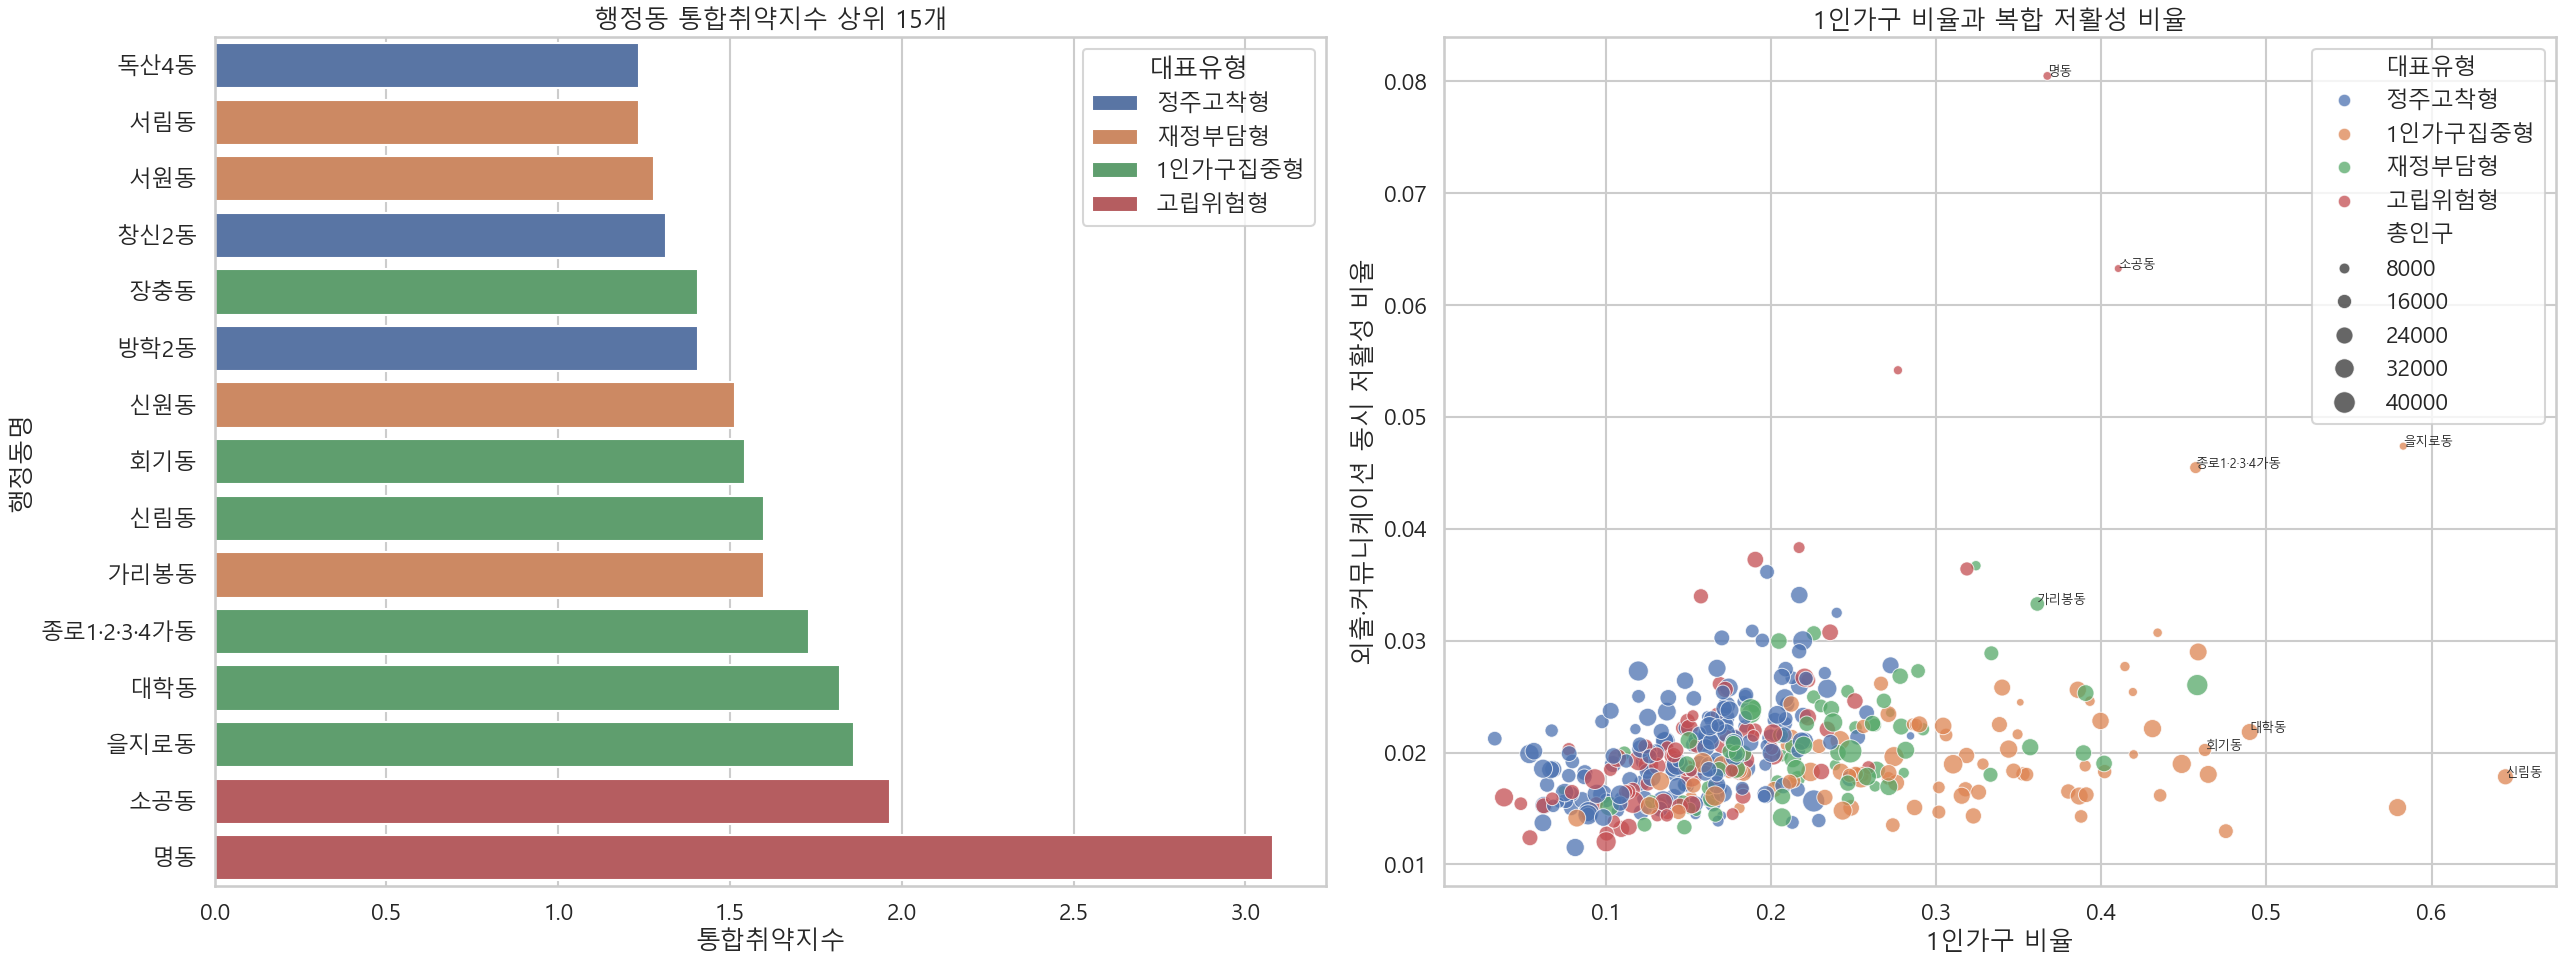

In [9]:
top_integrated = dong_df.sort_values("행정동통합취약지수", ascending=False).head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

sns.barplot(
    data=top_integrated.sort_values("행정동통합취약지수"),
    x="행정동통합취약지수",
    y="행정동명",
    hue="대표유형",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("행정동 통합취약지수 상위 15개")
axes[0].set_xlabel("통합취약지수")
axes[0].set_ylabel("행정동명")

scatter_df = dong_df.copy()
sns.scatterplot(
    data=scatter_df,
    x="1인가구수비율",
    y="외출-커뮤니케이션이 모두 적은 집단(전체)비율",
    hue="대표유형",
    size="총인구",
    sizes=(30, 280),
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("1인가구 비율과 복합 저활성 비율")
axes[1].set_xlabel("1인가구 비율")
axes[1].set_ylabel("외출·커뮤니케이션 동시 저활성 비율")

for _, row in top_integrated.head(8).iterrows():
    axes[1].text(row["1인가구수비율"], row["외출-커뮤니케이션이 모두 적은 집단(전체)비율"], row["행정동명"], fontsize=9)

plt.tight_layout()
plt.show()


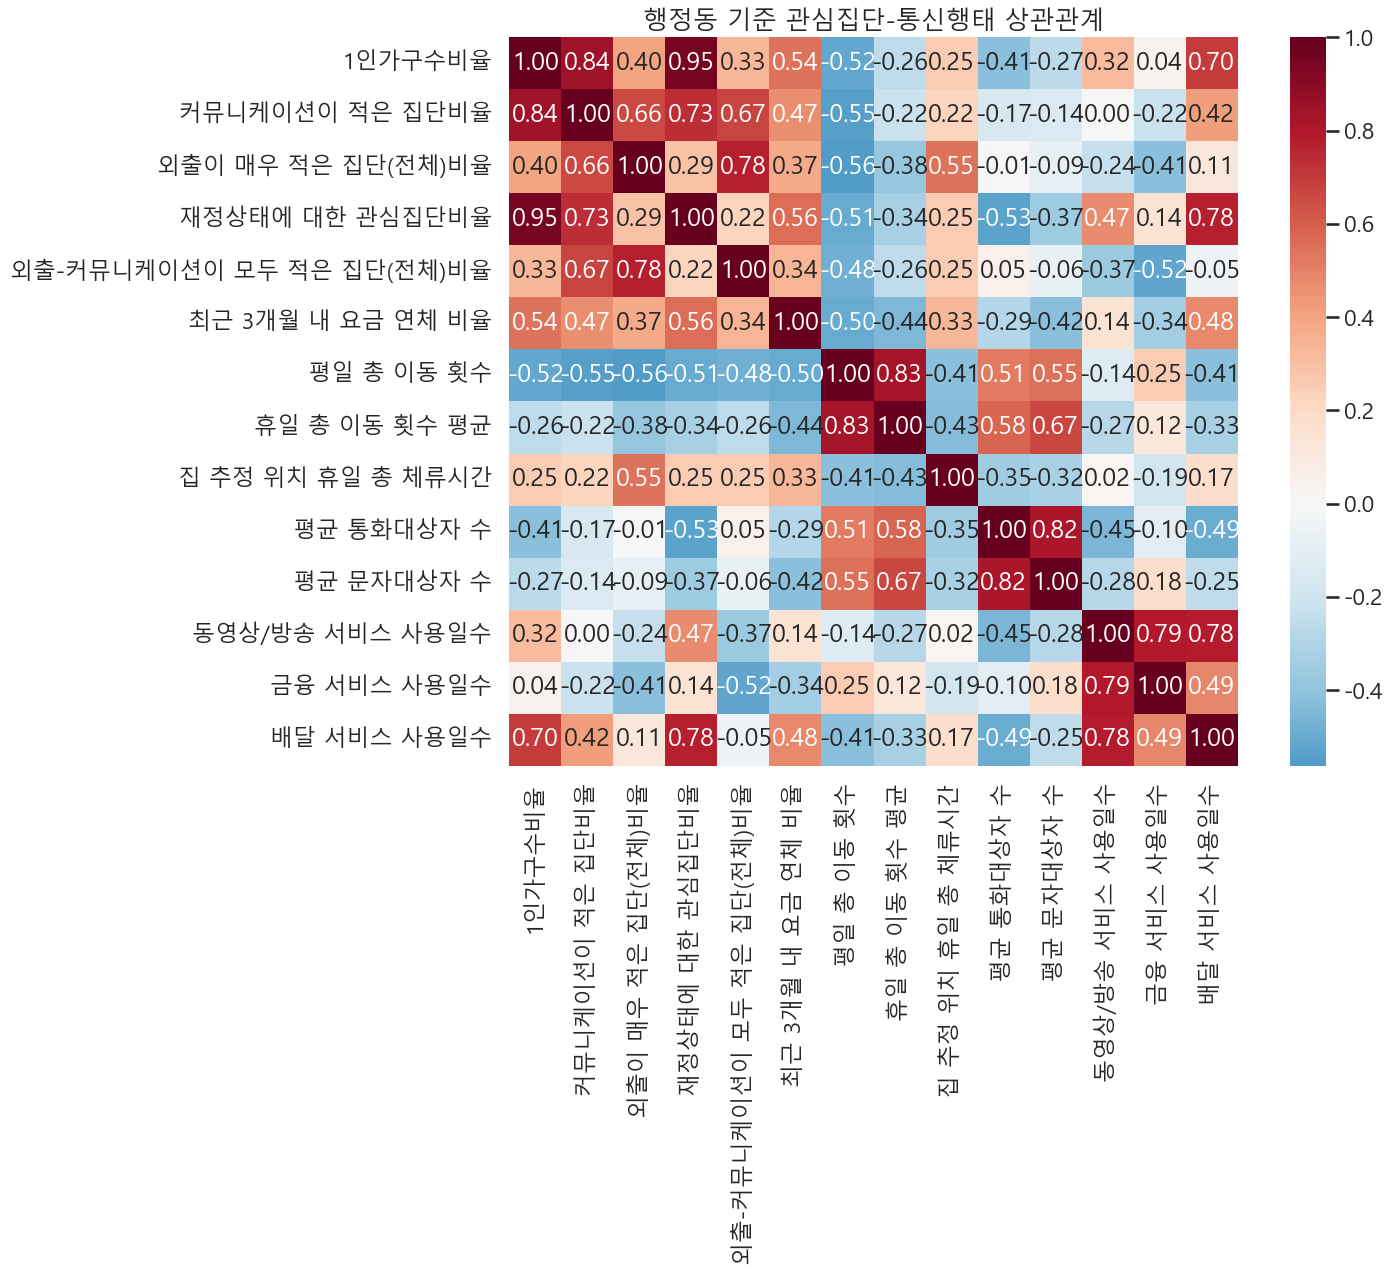

In [10]:
corr_cols = [
    "1인가구수비율",
    "커뮤니케이션이 적은 집단비율",
    "외출이 매우 적은 집단(전체)비율",
    "재정상태에 대한 관심집단비율",
    "외출-커뮤니케이션이 모두 적은 집단(전체)비율",
    "최근 3개월 내 요금 연체 비율",
    "평일 총 이동 횟수",
    "휴일 총 이동 횟수 평균",
    "집 추정 위치 휴일 총 체류시간",
    "평균 통화대상자 수",
    "평균 문자대상자 수",
    "동영상/방송 서비스 사용일수",
    "금융 서비스 사용일수",
    "배달 서비스 사용일수",
]
corr_cols = [c for c in corr_cols if c in dong_df.columns]
corr_matrix = dong_df[corr_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("행정동 기준 관심집단-통신행태 상관관계")
plt.tight_layout()
plt.show()


In [11]:
focus_ratio_cols = {
    "1인가구 비율": "1인가구수비율",
    "커뮤니케이션 저활성 비율": "커뮤니케이션이 적은 집단비율",
    "재정 관심 비율": "재정상태에 대한 관심집단비율",
    "복합 저활성 비율": "외출-커뮤니케이션이 모두 적은 집단(전체)비율",
    "요금 연체 비율": "최근 3개월 내 요금 연체 비율",
}

dong_top_tables = []
for label, col in focus_ratio_cols.items():
    if col not in dong_df.columns:
        continue
    top_row = dong_df.nlargest(1, col).iloc[0]
    dong_top_tables.append(
        {
            "지표": label,
            "자치구": top_row["자치구"],
            "행정동명": top_row["행정동명"],
            "총인구": int(top_row["총인구"]),
            "값": top_row[col],
            "대표유형": top_row["대표유형"],
        }
    )

pd.DataFrame(dong_top_tables)


,지표,자치구,행정동명,총인구,값,대표유형
0,1인가구 비율,관악구,신림동,21191,0.6448,1인가구집중형
1,커뮤니케이션 저활성 비율,중구,명동,4237,0.1234,고립위험형
2,재정 관심 비율,관악구,신림동,21191,0.0924,1인가구집중형
3,복합 저활성 비율,중구,명동,4237,0.0805,고립위험형
4,요금 연체 비율,강남구,역삼1동,38753,14.1870,재정부담형


## 5. 자동 행정동 인사이트

세 CSV를 결합한 결과를 바탕으로, 행정동 중심의 핵심 포인트를 자동으로 정리합니다.


In [12]:
top_integrated_row = dong_df.nlargest(1, "행정동통합취약지수").iloc[0]
top_single_row = dong_df.nlargest(1, "1인가구수비율").iloc[0]
top_overdue_row = dong_df.nlargest(1, "최근 3개월 내 요금 연체 비율").iloc[0]
top_home_row = dong_df.nlargest(1, "집 추정 위치 휴일 총 체류시간").iloc[0]
low_move_row = dong_df.nsmallest(1, "평일 총 이동 횟수").iloc[0]

high_risk_cut = dong_df["행정동통합취약지수"].quantile(0.90)
high_risk_dongs = dong_df[dong_df["행정동통합취약지수"] >= high_risk_cut].copy()
high_risk_gu = (
    high_risk_dongs.groupby("자치구")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="상위10% 행정동 수")
    .iloc[0]
)

type_dist = dong_df["대표유형"].value_counts().reset_index()
type_dist.columns = ["대표유형", "행정동 수"]

pop_gap_df = dong_df[dong_df["공공인구매칭여부"]].copy()
pop_gap_row = pop_gap_df.iloc[(pop_gap_df["데이터총인구_공공인구비"] - 1).abs().sort_values(ascending=False).index[0]]

insights = [
    f"1. 세 데이터 결합 기준 통합취약지수가 가장 높은 행정동은 {top_integrated_row['자치구']} {top_integrated_row['행정동명']}이며, 대표유형은 {top_integrated_row['대표유형']}입니다.",
    f"2. 1인가구 비율이 가장 높은 행정동은 {top_single_row['자치구']} {top_single_row['행정동명']}이며 비율은 {top_single_row['1인가구수비율']:.2%}입니다.",
    f"3. 최근 3개월 내 요금 연체 비율이 가장 높은 행정동은 {top_overdue_row['자치구']} {top_overdue_row['행정동명']}이며 비율은 {top_overdue_row['최근 3개월 내 요금 연체 비율']:.2%}입니다.",
    f"4. 휴일 기준 집 체류시간이 가장 긴 행정동은 {top_home_row['자치구']} {top_home_row['행정동명']}이며 평균 체류시간은 {top_home_row['집 추정 위치 휴일 총 체류시간']:,.1f}입니다.",
    f"5. 평일 총 이동 횟수가 가장 낮은 행정동은 {low_move_row['자치구']} {low_move_row['행정동명']}이며 평균 이동 횟수는 {low_move_row['평일 총 이동 횟수']:,.2f}입니다.",
    f"6. 통합취약지수 상위 10% 행정동이 가장 많이 분포한 자치구는 {high_risk_gu['자치구']}이며, 총 {int(high_risk_gu['상위10% 행정동 수'])}개 행정동이 포함됩니다.",
    f"7. 공공 인구가 매칭된 행정동 중 데이터 총인구와 공공 인구의 차이가 가장 큰 곳은 {pop_gap_row['자치구']} {pop_gap_row['행정동명']}이며, 비율은 {pop_gap_row['데이터총인구_공공인구비']:.2f}배입니다.",
    f"8. 전체 행정동에서 가장 많이 나타난 대표유형은 {type_dist.iloc[0]['대표유형']}이며 {int(type_dist.iloc[0]['행정동 수'])}개 행정동이 해당합니다.",
]

for line in insights:
    print(line)

display(type_dist)
display(high_risk_dongs[["자치구", "행정동명", "행정동통합취약지수", "대표유형"]].sort_values("행정동통합취약지수", ascending=False).head(20))


1. 세 데이터 결합 기준 통합취약지수가 가장 높은 행정동은 중구 명동이며, 대표유형은 고립위험형입니다.
2. 1인가구 비율이 가장 높은 행정동은 관악구 신림동이며 비율은 64.48%입니다.
3. 최근 3개월 내 요금 연체 비율이 가장 높은 행정동은 강남구 역삼1동이며 비율은 1418.70%입니다.
4. 휴일 기준 집 체류시간이 가장 긴 행정동은 종로구 가회동이며 평균 체류시간은 182,234.5입니다.
5. 평일 총 이동 횟수가 가장 낮은 행정동은 동대문구 회기동이며 평균 이동 횟수는 15.82입니다.
6. 통합취약지수 상위 10% 행정동이 가장 많이 분포한 자치구는 중구이며, 총 7개 행정동이 포함됩니다.
7. 공공 인구가 매칭된 행정동 중 데이터 총인구와 공공 인구의 차이가 가장 큰 곳은 서초구 반포4동이며, 비율은 1.09배입니다.
8. 전체 행정동에서 가장 많이 나타난 대표유형은 정주고착형이며 177개 행정동이 해당합니다.


,대표유형,행정동 수
0,정주고착형,177
1,1인가구집중형,88
2,고립위험형,86
3,재정부담형,73


,자치구,행정동명,행정동통합취약지수,대표유형
19,중구,명동,3.0818,고립위험형
17,중구,소공동,1.9654,고립위험형
23,중구,을지로동,1.8615,1인가구집중형
332,관악구,대학동,1.8206,1인가구집중형
7,종로구,종로1·2·3·4가동,1.7306,1인가구집중형
272,구로구,가리봉동,1.5991,재정부담형
329,관악구,신림동,1.5982,1인가구집중형
80,동대문구,회기동,1.5434,1인가구집중형
326,관악구,신원동,1.5133,재정부담형
148,도봉구,방학2동,1.4079,정주고착형


In [13]:
dong_export_cols = [
    "행정동코드", "자치구", "행정동명", "총인구", "행정동총인구_공공", "데이터총인구_공공인구비",
    "1인가구수비율", "커뮤니케이션이 적은 집단비율", "재정상태에 대한 관심집단비율",
    "외출-커뮤니케이션이 모두 적은 집단(전체)비율", "최근 3개월 내 요금 연체 비율",
    "평일 총 이동 횟수", "휴일 총 이동 횟수 평균", "집 추정 위치 휴일 총 체류시간",
    "평균 통화대상자 수", "동영상/방송 서비스 사용일수", "금융 서비스 사용일수",
    "배달 서비스 사용일수", "관심집단취약지수", "통신행동취약지수", "행정동통합취약지수", "대표유형"
]
dong_export_cols = [c for c in dong_export_cols if c in dong_df.columns]
dong_df[dong_export_cols].sort_values("행정동통합취약지수", ascending=False).head(30)


,행정동코드,자치구,행정동명,총인구,행정동총인구_공공,데이터총인구_공공인구비,1인가구수비율,커뮤니케이션이 적은 집단비율,재정상태에 대한 관심집단비율,외출-커뮤니케이션이 모두 적은 집단(전체)비율,최근 3개월 내 요금 연체 비율,평일 총 이동 횟수,휴일 총 이동 횟수 평균,집 추정 위치 휴일 총 체류시간,평균 통화대상자 수,동영상/방송 서비스 사용일수,금융 서비스 사용일수,배달 서비스 사용일수,관심집단취약지수,통신행동취약지수,행정동통합취약지수,대표유형
19,1102055,중구,명동,4237,"2,483.0000",1.7064,0.3672,0.1234,0.0194,0.0805,6.0408,16.1568,8.9493,"167,959.8317",13.8574,53.4093,123.1644,10.2948,5.6270,0.5367,3.0818,고립위험형
17,1102052,중구,소공동,2940,"2,198.0000",1.3376,0.4102,0.1173,0.0279,0.0633,5.4038,17.7296,10.1741,"140,074.6898",14.1310,62.5160,159.4214,11.9132,4.4561,-0.5254,1.9654,고립위험형
23,1102060,중구,을지로동,3102,"3,038.0000",1.0211,0.5828,0.1074,0.0516,0.0474,8.0996,18.8623,10.5621,"142,484.6769",14.4760,71.0543,181.7338,12.9964,4.2266,-0.5036,1.8615,1인가구집중형
332,1121073,관악구,대학동,24125,"24,982.0000",0.9657,0.4899,0.0587,0.0571,0.0218,10.4656,19.0276,9.3474,"176,519.2903",9.7529,75.0133,185.0399,14.4634,2.1676,1.4736,1.8206,1인가구집중형
7,1101061,종로구,종로1·2·3·4가동,10490,"6,659.0000",1.5753,0.4571,0.1031,0.0383,0.0455,8.2013,17.1927,9.8639,"134,958.7644",14.5557,65.4417,158.7965,12.7331,3.7665,-0.3053,1.7306,1인가구집중형
272,1117070,구로구,가리봉동,16854,"8,808.0000",1.9135,0.3612,0.0528,0.0358,0.0333,10.7522,17.5912,8.5429,"159,264.5554",11.1725,71.0774,161.0110,12.1335,1.8677,1.3305,1.5991,재정부담형
329,1121069,관악구,신림동,21191,"23,429.0000",0.9045,0.6448,0.0535,0.0924,0.0178,11.1519,20.6384,9.5334,"150,817.6746",10.2994,84.9179,216.6230,17.0202,2.6041,0.5923,1.5982,1인가구집중형
80,1106071,동대문구,회기동,13194,"10,319.0000",1.2786,0.4627,0.0375,0.0499,0.0202,6.2036,15.8174,9.0567,"162,358.2549",9.2949,77.4687,189.9268,15.0343,1.3889,1.6978,1.5434,1인가구집중형
326,1121065,관악구,신원동,17766,"17,188.0000",1.0336,0.3333,0.0356,0.0432,0.0289,9.3584,19.1895,8.6948,"170,653.3160",10.6687,75.9347,191.0072,14.3395,1.6272,1.3994,1.5133,재정부담형
148,1110056,도봉구,방학2동,17428,"17,575.0000",0.9916,0.1974,0.0252,0.0215,0.0361,11.6395,18.3677,8.7562,"182,081.7337",11.3395,68.4508,158.6481,12.0149,0.9735,1.8423,1.4079,정주고착형
